# Universidad de Antioquia

## Facultad de Ingeniería  

---

# Práctica 2 de Laboratorio

**Asignatura:** Control Continuo

**Docente:** Hernán Felipe García

**Estudiante:** Santiago Castaño Loaiza

**Fecha:** Marzo 2026  

---

## Descripción

En este notebook se desarrolla la implementación y análisis del proyecto correspondiente a la segunda práctica de laboratorio.


### 3.2 Descripción de comandos de Python para Control

A continuación se presenta una descripción breve y clara de los comandos solicitados, frecuentemente utilizados en la biblioteca `python-control`:

* **`tic`, `toc`, `time`**: Se utilizan para medir el tiempo de ejecución de un proceso. En Python, se suele importar el módulo `time` y usar `time.time()` para capturar el tiempo de inicio (`tic`) y el tiempo final (`toc`).
* **`tf`**: Crea un modelo de sistema dinámico en forma de Función de Transferencia a partir de los coeficientes de su numerador y denominador.
* **`ss`**: Crea un modelo de sistema en el Espacio de Estados a partir de las matrices dinámicas A, B, C y D.
* **`zpk`**: Define un modelo de sistema especificando explícitamente sus Ceros, Polos y su Ganancia.
* **`tf2ss`**: Convierte un modelo de Función de Transferencia a su representación equivalente en el Espacio de Estados.
* **`tf2zp`**: Convierte un modelo de Función de Transferencia a su representación de Ceros, Polos y Ganancia.
* **`ss2zp`**: Transforma un modelo del Espacio de Estados a formato de Ceros, Polos y Ganancia.
* **`ss2tf`**: Transforma un modelo del Espacio de Estados a su equivalente como Función de Transferencia.
* **`zp2ss`**: Convierte un sistema expresado en Ceros, Polos y Ganancia a su representación en el Espacio de Estados.
* **`zp2tf`**: Convierte un sistema expresado en Ceros, Polos y Ganancia a Función de Transferencia.
* **`roots`**: Calcula las raíces de un polinomio a partir de sus coeficientes.
* **`pole`**: Retorna los polos de un sistema dinámico (las raíces de su ecuación característica).
* **`zero`**: Retorna los ceros del sistema dinámico.
* **`poly`**: Construye los coeficientes de un polinomio a partir de un conjunto dado de raíces.
* **`eig`**: Calcula los valores y vectores propios de una matriz cuadrada (útil para la matriz A del Espacio de Estados).
* **`pzmap`**: Genera un gráfico que muestra la ubicación de los polos y ceros del sistema en el plano complejo.
* **`dcgain`**: Calcula la ganancia estática o de corriente continua (DC) del sistema, evaluando su respuesta cuando la frecuencia es cero.
* **`minreal`**: Simplifica un modelo dinámico cancelando pares de polos y ceros que coinciden, obteniendo una realización mínima.
* **`subplot`**: Comando para dividir una ventana de figura en una cuadrícula y mostrar múltiples gráficas simultáneamente.
* **`feedback`**: Calcula el modelo resultante de la interconexión de dos sistemas en un lazo de retroalimentación.
* **`tfdata`**: Extrae y devuelve los coeficientes del numerador y denominador almacenados en un objeto de Función de Transferencia.

### 3.3 Conceptos de Control

* **Polinomio característico de un sistema:** Es el polinomio que se obtiene al igualar a cero el denominador de la función de transferencia de un sistema el cual puede estar en lazo abierto o cerrado. En la representación de espacio de estados, se calcula como: $det(sI - A) = 0$. Las raíces de este polinomio definen la estabilidad del sistema. 
* **Valores propios de un sistema:** Matemáticamente, son los escalares $\lambda$ que resuelven la ecuación característica $det(\lambda I - A) = 0$. Los valores propios de la matriz del sistema ($A$) son equivalentes a los polos de la función de transferencia. Su ubicación en el plano complejo determina si el sistema es estable y cómo es su comportamiento oscilatorio.
* **Tiempo de estabilización:** ($t_s$), es el tiempo que tarda la respuesta temporal de un sistema en alcanzar y mantenerse dentro de una banda de error o tolerancia específica (generalmente del 1%, lo que equivale a $5\tau$) de su valor final en estado estacionario, tras aplicarle una entrada tipo escalón.
* **Sobre nivel porcentual (Overshoot o $\%OS$):** Es la cantidad máxima por la cual la respuesta transitoria de un sistema supera su valor final de estado estable. Se expresa como un porcentaje de dicho valor final y es un indicador directo de qué tan oscilatorio (subamortiguado) es el sistema.

### Ejemplos

**1. Polinomio Característico:**
Para un sistema con función de transferencia $G(s)=\frac{5}{s^2+4s+3}$, su polinomio característico es simplemente el denominador igualado a cero:
$$s^2+4s+3=0$$

**2. Valores Propios (Polos):**
Al resolver el polinomio anterior, factorizamos como $(s+1)(s+3)=0$. Los valores propios son las raíces de esa ecuación: $s_1=-1$ y $s_2=-3$.

**3. Sobre Nivel Porcentual y Tiempo de Estabilización:**
Si le damos a un motor la orden de girar a 100 RPM:
* **Sobre nivel porcentual:** Si en el arranque la velocidad alcanza un pico de 112 RPM antes de corregirse, tenemos un sobre nivel del 12%.
* **Tiempo de estabilización:** Si el motor tarda 2.5 segundos en quedarse girando de forma estable (dentro de un margen aceptable) en las 100 RPM, ese es su tiempo de estabilización.

### 5.1 Modelo de Función de Transferencia y Espacio de Estados sin Tiempo Muerto

**Modelo de FT sin tiempo muerto:**
Con $T_m = 0$, la expresión algebraica queda:
$$G(s) = \frac{k}{(\tau_1s+1)(\tau_2s+1)}$$

Reemplazando con los valores numéricos del sistema:
$$G(s) = \frac{1.2}{(59.7s+1)(22.3s+1)}$$

Si expandimos el denominador ($59.7 \times 22.3 = 1331.31$) y dividimos todo por ese valor para que la derivada mayor ($s^2$) quede con coeficiente 1, se expresa así:
$$G(s) = \frac{\frac{1.2}{1331.31}}{s^2 + \frac{82}{1331.31}s + \frac{1}{1331.31}}$$

---

### 5.1 Modelo de Espacio de Estados sin Tiempo Muerto (Algebraico)

**Paso 1: Función de Transferencia base**
Partimos de la relación entre la salida $Y(s)$ y la entrada $U(s)$ utilizando las constantes del sistema. Expandimos el denominador y dividimos por $\tau_1\tau_2$ para garantizar que el término de mayor orden ($s^2$) quede con coeficiente igual a 1:
$$G(s) = \frac{Y(s)}{U(s)} = \frac{\frac{k}{\tau_1\tau_2}}{s^2 + \frac{\tau_1+\tau_2}{\tau_1\tau_2}s + \frac{1}{\tau_1\tau_2}}$$

**Paso 2: Transformación a ecuación lineal**
Multiplicamos en cruz para eliminar los denominadores y agrupar los términos:
$$Y(s) \cdot \left(s^2 + \frac{\tau_1+\tau_2}{\tau_1\tau_2}s + \frac{1}{\tau_1\tau_2}\right) = U(s) \cdot \left(\frac{k}{\tau_1\tau_2}\right)$$

Distribuyendo la variable de salida $Y(s)$, obtenemos:
$$s^2Y(s) + \frac{\tau_1+\tau_2}{\tau_1\tau_2}sY(s) + \frac{1}{\tau_1\tau_2}Y(s) = \frac{k}{\tau_1\tau_2}U(s)$$

**Paso 3: Paso al dominio del tiempo**
Aplicamos la transformada inversa de Laplace para convertir el modelo en una ecuación diferencial, recordando que multiplicar por $s$ en el dominio frecuencial equivale a derivar en el dominio del tiempo:
$$y''(t) + \frac{\tau_1+\tau_2}{\tau_1\tau_2}y'(t) + \frac{1}{\tau_1\tau_2}y(t) = \frac{k}{\tau_1\tau_2}u(t)$$

**Paso 4: Despeje de la mayor derivada**
Aislamos la segunda derivada $y''(t)$ al lado izquierdo de la ecuación:
$$y''(t) = -\frac{1}{\tau_1\tau_2}y(t) - \frac{\tau_1+\tau_2}{\tau_1\tau_2}y'(t) + \frac{k}{\tau_1\tau_2}u(t)$$

**Paso 5: Definición de Variables de Estado de Fase (VEF)**
Para reducir el orden de la ecuación, definimos nuestras variables de estado tomando $x_1(t)=y(t)$ y $x_2(t)=y'(t)$. Al derivar estas nuevas variables, obtenemos nuestras ecuaciones de estado:

1.  La derivada de la primera variable es directamente la segunda variable:
    $$\dot{x}_1(t) = x_2(t)$$
2.  La derivada de la segunda variable es $y''(t)$, la cual reemplazamos con la ecuación obtenida en el Paso 4:
    $$\dot{x}_2(t) = -\frac{1}{\tau_1\tau_2}x_1(t) - \frac{\tau_1+\tau_2}{\tau_1\tau_2}x_2(t) + \frac{k}{\tau_1\tau_2}u(t)$$

**Paso 6: Ecuación de Salida**
Finalmente, establecemos que la respuesta del sistema corresponde a la primera variable de estado:
$$y(t) = x_1(t)$$

### Definición de Variables y Matrices para Python (Punto 5.2)

Antes de programar, definimos numéricamente los componentes de nuestros dos modelos (sin tiempo muerto), sabiendo que $\tau_1\tau_2 = 1331.31$ y $\tau_1+\tau_2 = 82$, con una ganancia $k = 1.2$.

**Para la Función de Transferencia (FT):**
El numerador (`num`) y denominador (`den`) se definen a partir de los coeficientes del polinomio $G(s) = \frac{1.2}{1331.31s^2 + 82s + 1}$:
* `num` = $[1.2]$
* `den` = $[1331.31, 82, 1]$

**Para el Espacio de Estados (EE):**
A partir de las ecuaciones de Variables de Estado de Fase, organizamos el sistema matricial $\dot{x} = Ax + Bu$ y $y = Cx + Du$:

$$A = \begin{bmatrix} 0 & 1 \\ -\frac{1}{1331.31} & -\frac{82}{1331.31} \end{bmatrix}$$

$$B = \begin{bmatrix} 0 \\ \frac{1.2}{1331.31} \end{bmatrix}$$

$$C = \begin{bmatrix} 1 & 0 \end{bmatrix}$$

$$D = \begin{bmatrix} 0 \end{bmatrix}$$

### 5.2 Implementación Computacional y Respuesta al Escalón

Una vez definidas nuestras matrices y coeficientes algebraicos, procedemos a trasladar esta información a Python utilizando la biblioteca `control`. Crearemos ambos modelos (Función de Transferencia y Espacio de Estados) y simularemos su respuesta ante una entrada tipo escalón de amplitud 0.23.

In [2]:
%pip install control

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


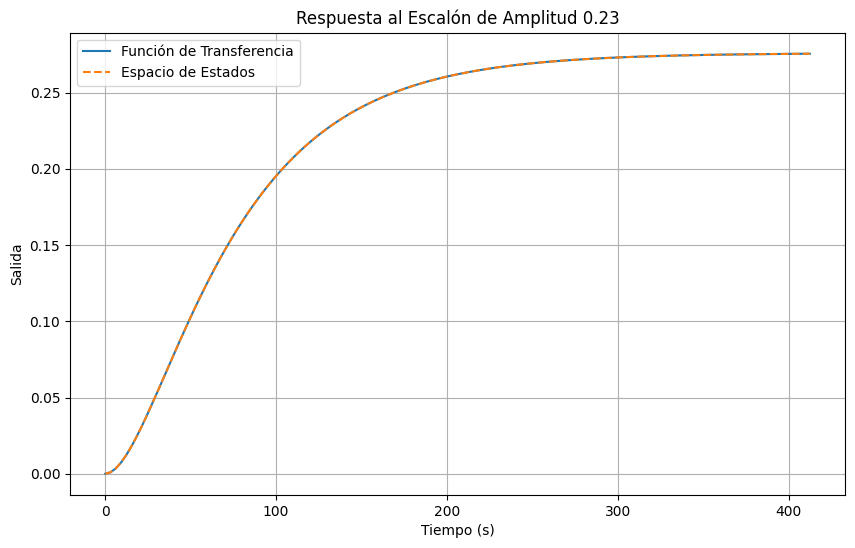

In [4]:
import control as ctrl
import matplotlib.pyplot as plt 

# Para la Función de Transferencia sin tiempo muerto:
num = [1.2]
den = [1331.31, 82, 1]
Gptf = ctrl.tf(num, den)

# Para el Espacio de Estados sin tiempo muerto:
A = [[0, 1], [-1/1331.31, -82/1331.31]]
B = [[0], [1.2/1331.31]]
C = [[1, 0]]
D = [[0]]
Mpss = ctrl.ss(A, B, C, D)

# 3. Simulación de respuesta ante escalón de amplitud 0.23
t_tf, y_tf = ctrl.step_response(Gptf * 0.23)
t_ss, y_ss = ctrl.step_response(Mpss * 0.23)

# Grafica de la respuesta al escalón
plt.figure(figsize=(10,6))
plt.plot(t_tf, y_tf, label = 'Función de Transferencia')
plt.plot(t_ss, y_ss, label = 'Espacio de Estados', linestyle='dashed')
plt.title('Respuesta al Escalón de Amplitud 0.23')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida')
plt.grid()
plt.legend()
plt.show()

### Análisis de Resultados (5.2.1 y 5.2.2)

**5.2.1 ¿Cuál es el valor final de las respuestas anteriores?**

El valor final de la respuesta en estado estacionario es **0.276**. 
*Justificación:* El sistema posee una ganancia estática ($k$) de 1.2. Al aplicar una entrada tipo escalón con una amplitud de 0.23, la salida final se determina multiplicando dicha entrada por la ganancia del sistema:
$$y(\infty) = 0.23 \times 1.2 = 0.276$$
Al observar la gráfica generada, se comprueba visualmente que la curva de salida tiende de forma asintótica y se estabiliza exactamente en este valor, justo por debajo de la línea del 0.3 en el eje Y.

**5.2.2 ¿Cuáles son los tiempos de estabilización de las respuestas?**

El tiempo de estabilización es de aproximadamente **298.5 segundos**.
*Justificación:* Tomando como referencia el criterio de la banda de error del 1%, el tiempo de estabilización ($t_s$) de un sistema sobreamortiguado se aproxima a 5 veces su constante de tiempo dominante ($5\tau$). Dado que la constante de tiempo mayor de nuestro sistema es $\tau_1 = 59.7$ s, calculamos:
$$t_s \approx 5\tau_1 = 5 \times 59.7 = 298.5 \text{ s}$$
Este cálculo teórico concuerda con la gráfica obtenida, donde se evidencia que poco antes de la marca de los 300 segundos, la respuesta transitoria ha concluido y la señal se mantiene plana dentro de la tolerancia de su valor final.

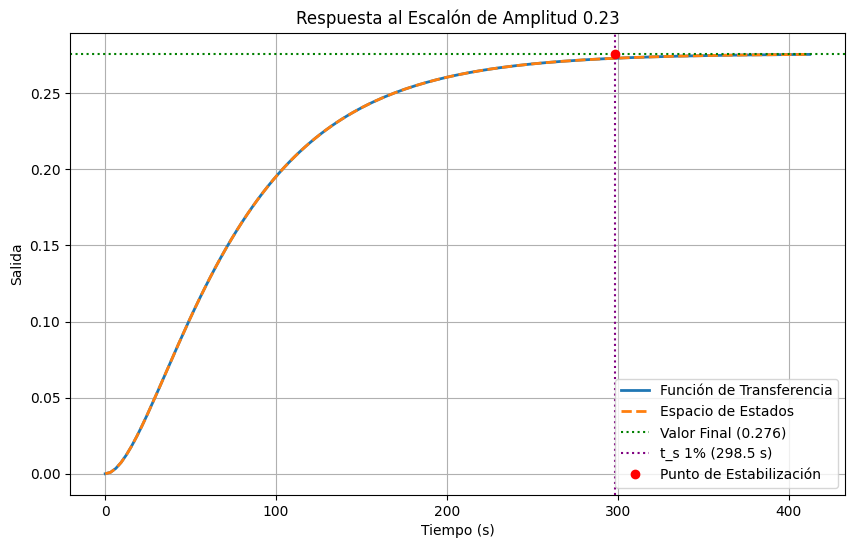

In [5]:
plt.figure(figsize=(10,6))
plt.plot(t_tf, y_tf, label='Función de Transferencia', linewidth=2)
plt.plot(t_ss, y_ss, label='Espacio de Estados', linestyle='dashed', linewidth=2)

plt.axhline(y=0.276, color='green', linestyle=':', linewidth=1.5, label='Valor Final (0.276)')

plt.axvline(x=298.5, color='purple', linestyle=':', linewidth=1.5, label='t_s 1% (298.5 s)')

plt.plot(298.5, 0.276, 'ro', label='Punto de Estabilización')

plt.title('Respuesta al Escalón de Amplitud 0.23')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida')
plt.grid()
plt.legend(loc='lower right') 
plt.show()

### 5.3 y 5.3.1 Inclusión del Tiempo Muerto (Aproximación de Padé)

In [6]:
import control as ctrl

print("--- Inspección del modelo Gptf ---")
print("Numerador:", Gptf.num[0][0])
print("Denominador:", Gptf.den[0][0])

print("\n--- Inspección del modelo Mpss ---")
print("Matriz A:\n", Mpss.A)
print("Matriz B:\n", Mpss.B)

tiempo_muerto = 39.2

# 1. Creamos la aproximación de Padé (usaremos orden n=4 para buena precisión)
num_pade, den_pade = ctrl.pade(tiempo_muerto, n=4)
G_pade = ctrl.tf(num_pade, den_pade)

# 2. Nuevo modelo Gptfm (Función de Transferencia con Tiempo Muerto)
# Multiplicamos el sistema original por la aproximación de Padé (Conexión en serie)
Gptfm = ctrl.series(Gptf, G_pade)

# 3. Nuevo modelo Mpssm (Espacio de Estados con Tiempo Muerto)
# Convertimos el bloque de Padé a Espacio de Estados y lo multiplicamos por Mpss
M_pade = ctrl.tf2ss(G_pade)
Mpssm = ctrl.series(Mpss, M_pade)

# 4. Verificación de que los modelos incluyen el tiempo muerto
print("\n--- Verificación Gptfm ---")
print(Gptfm)

print("\n--- Verificación Mpssm ---")
print(Mpssm)

--- Inspección del modelo Gptf ---
Numerador: [1.2]
Denominador: [1.33131e+03 8.20000e+01 1.00000e+00]

--- Inspección del modelo Mpss ---
Matriz A:
 [[ 0.00000000e+00  1.00000000e+00]
 [-7.51139855e-04 -6.15934681e-02]]
Matriz B:
 [[0.        ]
 [0.00090137]]

--- Verificación Gptfm ---
<TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             1.2 s^4 - 0.6122 s^3 + 0.1406 s^2 - 0.01673 s + 0.0008538
  --------------------------------------------------------------------------------
  1331 s^6 + 761.2 s^5 + 198.8 s^4 + 28.68 s^3 + 2.208 s^2 + 0.07229 s + 0.0007115

--- Verificación Mpssm ---
<StateSpace>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (6): ['x[0]', 'x[1]', 'x[2]', 'x[3]', 'x[4]', 'x[5]']

A = [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
       0.00000000e+00  0.00000000e+00]
     [-7.51139855e-04 -6.15934681e-02  0.00000000e+00  0.00000000e+00
       0.00000000e+00  0.00000000e+00]
     [ 1.00000000e+00  0.00000

### 5.3.2 Respuesta de los modelos con tiempo muerto

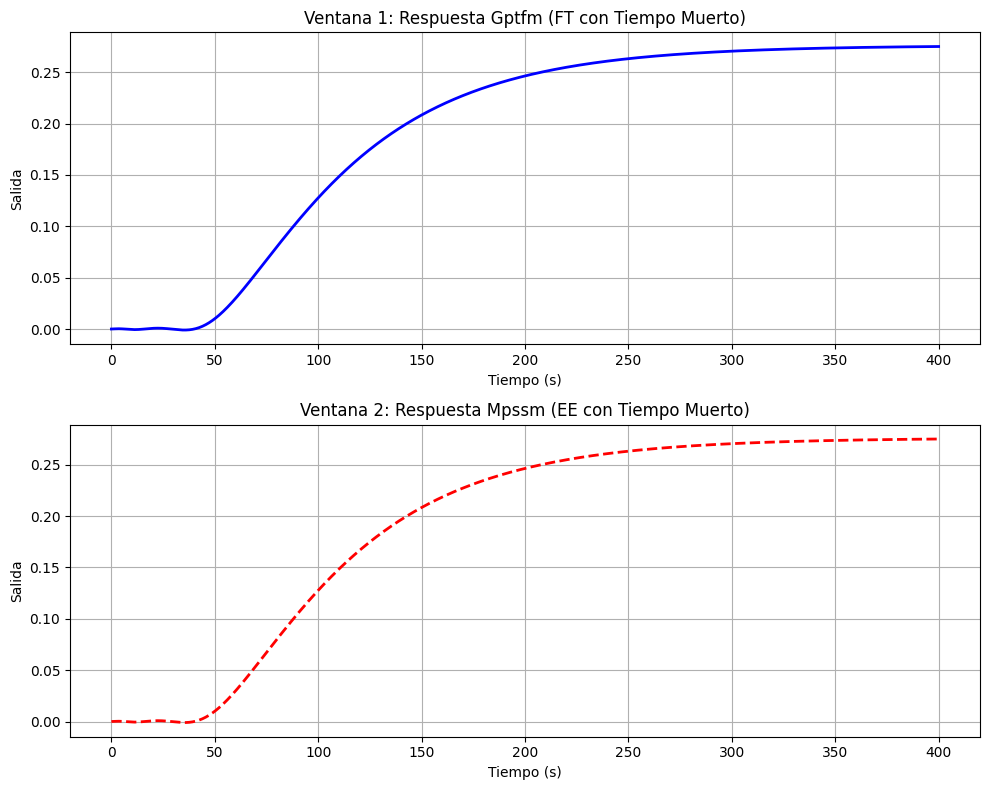

In [7]:
import numpy as np

t_sim = np.linspace(0, 400, 1000)
amplitud_escalon = 0.23

# Simulamos las respuestas
t_tfm, y_tfm = ctrl.step_response(amplitud_escalon * Gptfm, T=t_sim)
t_ssm, y_ssm = ctrl.step_response(amplitud_escalon * Mpssm, T=t_sim)

# Ejecutamos el comando figure para crear la ventana
plt.figure(figsize=(10, 8))

# Ventana 1 de subplot: Función de Transferencia con Tiempo Muerto (Gptfm)
plt.subplot(2, 1, 1)
plt.plot(t_tfm, y_tfm, 'b-', linewidth=2)
plt.title('Ventana 1: Respuesta Gptfm (FT con Tiempo Muerto)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida')
plt.grid(True)

# Ventana 2 de subplot: Espacio de Estados con Tiempo Muerto (Mpssm)
plt.subplot(2, 1, 2)
plt.plot(t_ssm, y_ssm, 'r--', linewidth=2)
plt.title('Ventana 2: Respuesta Mpssm (EE con Tiempo Muerto)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida')
plt.grid(True)

# Ajustamos espacios para que no se traslapen los textos
plt.tight_layout()

# Mostramos la gráfica (se mantiene abierta en el output de Jupyter/VS Code)
plt.show()

### 5.3.3 Extracción de variables al ETPython

In [10]:
NUM = Gptfm.num[0][0]
DEN = Gptfm.den[0][0]

# Dejamos en memoria las variables del EE
A = Mpssm.A
B = Mpssm.B
C = Mpssm.C
D = Mpssm.D

# Guardamos la variable de tiempo muerto
TM = 39.2

print("=========================================")
print(" VALORES EXTRAÍDOS Y GUARDADOS (TM = 39.2s)")
print("=========================================")

print("\n--- Función de Transferencia (Gptfm) ---")
print("Numerador (NUM):")
print(NUM)
print("\nDenominador (DEN):")
print(DEN)

print("\n--- Espacio de Estados (Mpssm) ---")
print("Matriz A:")
print(A)
print("\nMatriz B:")
print(B)
print("\nMatriz C:")
print(C)
print("\nMatriz D:")
print(D)

print("\n--- Variable de Tiempo Muerto ---")
print(f"TM: {TM}")

 VALORES EXTRAÍDOS Y GUARDADOS (TM = 39.2s)

--- Función de Transferencia (Gptfm) ---
Numerador (NUM):
[ 1.20000000e+00 -6.12244898e-01  1.40566431e-01 -1.67340989e-02
  8.53780555e-04]

Denominador (DEN):
[1.33131000e+03 7.61239796e+02 1.98784647e+02 2.86808045e+01
 2.20784094e+00 7.22867537e-02 7.11483796e-04]

--- Espacio de Estados (Mpssm) ---
Matriz A:
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-7.51139855e-04 -6.15934681e-02  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00 -5.10204082e-01 -1.17138692e-01
  -1.39450824e-02 -7.11483796e-04]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00]]

Matriz B:
[[0.        ]
 [0.0009

### 5.3.4 Extracción de información de las estructuras (Sin tiempo muerto)

In [11]:
# 1. Ceros del sistema (Raíces del numerador)
ceros = ctrl.zeros(Gptf)

# 2. Polos del sistema (Raíces del denominador)
polos = ctrl.poles(Gptf)

# 3. Valores propios del sistema (Eigenvalues de la matriz A)
valores_propios = np.linalg.eigvals(Mpss.A)

# 4. Polinomio característico (Coeficientes del denominador o det(sI - A))
polinomio_caracteristico = Gptf.den[0][0] 

# 5. Ganancia DC del sistema
ganancia_dc = ctrl.dcgain(Gptf)

# Impresión de resultados para el informe
print("--- RESULTADOS 5.3.4 ---")
print(f"Ceros del sistema: {ceros}")
print(f"Polos del sistema: {polos}")
print(f"Valores propios del sistema: {valores_propios}")
print(f"Polinomio característico del sistema: {polinomio_caracteristico}")
print(f"Ganancia DC del sistema: {ganancia_dc}")

--- RESULTADOS 5.3.4 ---
Ceros del sistema: []
Polos del sistema: [-0.04484305+0.j -0.01675042+0.j]
Valores propios del sistema: [-0.01675042 -0.04484305]
Polinomio característico del sistema: [1.33131e+03 8.20000e+01 1.00000e+00]
Ganancia DC del sistema: 1.2


Para este análisis, se utilizaron los modelos **sin tiempo muerto** (`Gptf` y `Mpss`). La justificación técnica de esta decisión radica en que la aproximación de Padé introduce "polos y ceros falsos" (artificios matemáticos en el plano complejo) para simular el retardo temporal. Si extrajéramos la información del modelo con Padé, observaríamos una dinámica que no pertenece físicamente a la planta de los tanques. 

**Ceros del sistema:**
`[]` 
*(El arreglo está vacío. Esto confirma matemáticamente que el sistema físico real no tiene ceros, ya que su numerador es simplemente una constante y no depende de la variable $s$).*

**Polos del sistema:**
`[-0.04484305+0.j  -0.01675042+0.j]` 
*(Corresponden a las raíces del denominador. El término `+0.j` indica que la parte imaginaria es cero, confirmando que los polos son reales puros y, por tanto, el sistema es sobreamortiguado. Sus valores equivalen exactamente a $-1/\tau_2$ y $-1/\tau_1$).*

**Valores propios del sistema:**
`[-0.01675042 -0.04484305]` 
*(Extraídos de la matriz $A$. Son idénticos a los polos de la Función de Transferencia, lo que demuestra la equivalencia absoluta entre ambas representaciones matemáticas).*

**Polinomio característico del sistema:**
`[1.33131e+03 8.20000e+01 1.00000e+00]` 
*(Representación en notación científica de los coeficientes del denominador. Equivale exactamente a la ecuación $1331.31s^2 + 82s + 1 = 0$).*

**Ganancia DC del sistema (ganancia a frecuencia cero):**
`1.2` 
*(Corresponde a la constante $k$ del sistema, verificando que ante un cambio unitario sostenido, la salida se multiplicará por este factor en estado estacionario).*

### 5.4 Conversión de Estructuras

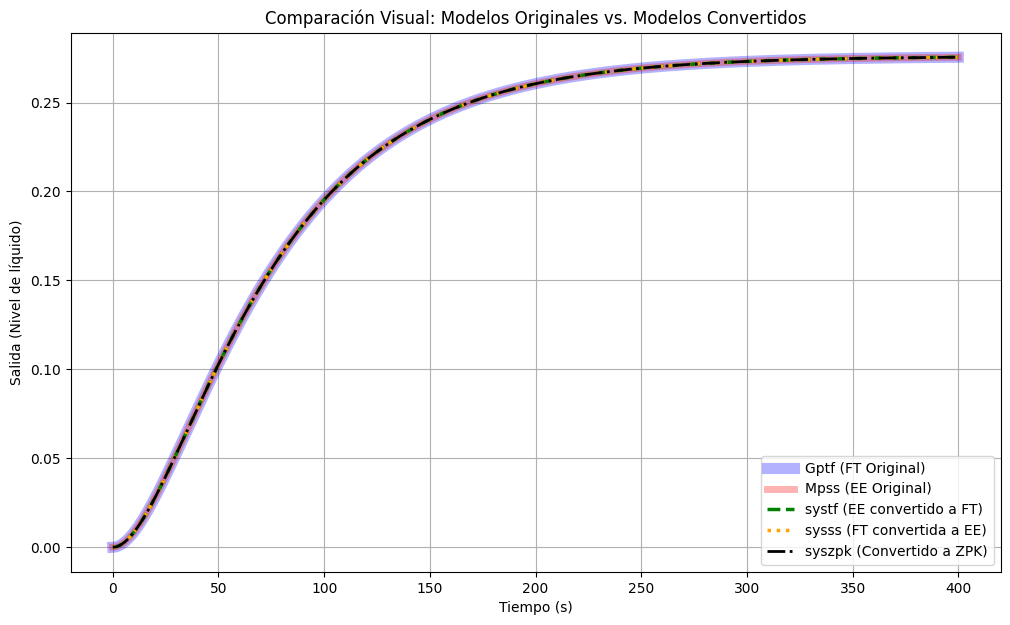

In [14]:
num = [1.2]
den = [1331.31, 82, 1]
Gptf = ctrl.tf(num, den)

A = [[0, 1], [-1/1331.31, -82/1331.31]]
B = [[0], [1.2/1331.31]]
C = [[1, 0]]
D = [[0]]
Mpss = ctrl.ss(A, B, C, D)

systf = ctrl.tf(Mpss)
sysss = ctrl.ss(Gptf)

ceros = ctrl.zeros(Gptf)
polos = ctrl.poles(Gptf)
ganancia_zpk = Gptf.num[0][0][0] / Gptf.den[0][0][0]
syszpk = ctrl.zpk(ceros, polos, ganancia_zpk)

# 3. Simulamos todos ante un escalón de 0.23
t_sim = np.linspace(0, 400, 1000)
amp = 0.23

t_1, y_1 = ctrl.step_response(amp * Gptf, T=t_sim)
t_2, y_2 = ctrl.step_response(amp * Mpss, T=t_sim)
t_3, y_3 = ctrl.step_response(amp * systf, T=t_sim)
t_4, y_4 = ctrl.step_response(amp * sysss, T=t_sim)
t_5, y_5 = ctrl.step_response(amp * syszpk, T=t_sim)

# 4. Graficamos superponiendo con distintos estilos
plt.figure(figsize=(12, 7))

plt.plot(t_1, y_1, label='Gptf (FT Original)', color='blue', linewidth=8, alpha=0.3)
plt.plot(t_2, y_2, label='Mpss (EE Original)', color='red', linewidth=5, alpha=0.3)

plt.plot(t_3, y_3, label='systf (EE convertido a FT)', color='green', linestyle='dashed', linewidth=2.5)
plt.plot(t_4, y_4, label='sysss (FT convertida a EE)', color='orange', linestyle='dotted', linewidth=2.5)
plt.plot(t_5, y_5, label='syszpk (Convertido a ZPK)', color='black', linestyle='dashdot', linewidth=2)

plt.title('Comparación Visual: Modelos Originales vs. Modelos Convertidos')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida (Nivel de líquido)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 5.4 Conversión de Estructuras

**¿Existen otras opciones de conversión de estructuras?**
Sí. Además de las transformaciones entre Función de Transferencia (`tf`), Espacio de Estados (`ss`) y Ceros-Polos-Ganancia (`zpk`), existen otras conversiones fundamentales en control. Por ejemplo:
* Conversión a modelos de datos de Respuesta en Frecuencia (`frd` - Frequency Response Data).
* Conversión de modelos continuos a modelos en tiempo discreto (mediante el comando `sample_system` o equivalente a `c2d`).

**¿systf y sysss son iguales a las expresiones Gptf y Mpss que usted manejó en 5.2?**
* **`systf` vs `Gptf`**: Sí, matemáticamente son idénticas. Al convertir el Espacio de Estados a Función de Transferencia, se recupera el mismo polinomio (aunque por redondeo numérico de la máquina puedan aparecer coeficientes residuales diminutos cercanos a cero, como $10^{-16}$).
* **`sysss` vs `Mpss`**: **NO son iguales.** Las matrices $A, B, C$ y $D$ generadas por `ss(Gptf)` son completamente diferentes a las físicas de `Mpss`. Esto ocurre porque al convertir una FT a EE, el software construye por defecto una representación matemática en **forma canónica** (como la forma canónica controlable). Al hacer esto, los estados pierden su significado físico original (las alturas de los tanques $h_1$ y $h_2$).

**Comentario:**
Estos resultados evidencian una propiedad clave de los sistemas LTI (Lineales Invariantes en el Tiempo): **La Función de Transferencia de un sistema es única, pero su representación en Espacio de Estados no lo es**. Existen infinitas combinaciones de matrices que pueden modelar exactamente la misma dinámica de entrada-salida, dependiendo de cómo se definan matemáticamente sus variables de estado internas. 

### 5.5 Respuesta al escalón unitario del sistema Gptfm 

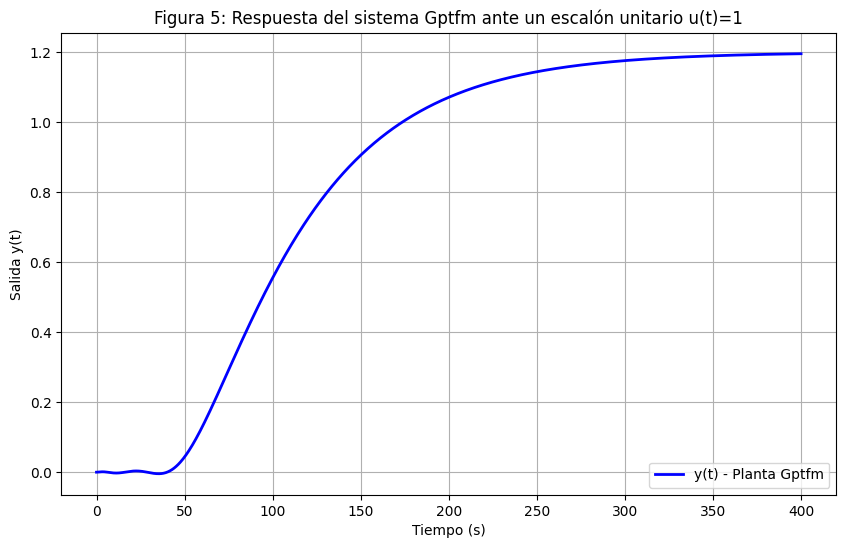

In [15]:
t_sim = np.linspace(0, 400, 1000)

# Simulamos la respuesta al ESCALÓN UNITARIO (por defecto step_response usa amplitud 1)
t_fig5, y_fig5 = ctrl.step_response(Gptfm, T=t_sim)

plt.figure(figsize=(10, 6))

# Graficamos la respuesta
plt.plot(t_fig5, y_fig5, 'b-', linewidth=2, label='y(t) - Planta Gptfm')
plt.title('Figura 5: Respuesta del sistema Gptfm ante un escalón unitario u(t)=1')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida y(t)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

### 5.5.1 Relaciones de Transferencia (Figura 6)

Para encontrar las Funciones de Transferencia, primero planteamos las ecuaciones algebraicas de cada bloque y nodo del sistema en el dominio de Laplace, teniendo en cuenta todas las señales intermedias:

1. **Señal del controlador:** $$M(s) = G_c(s) \cdot E(s)$$

2. **Señal en el nodo de suma (Entrada a la planta):** $$U(s) = M(s) + P(s)$$

3. **Señal de salida del sistema:** $$Y(s) = Gptfm(s) \cdot U(s)$$

Para encontrar la relación directa de la salida con las entradas, sustituimos la ecuación (2) en la ecuación (3):
$$Y(s) = Gptfm(s) \cdot [M(s) + P(s)]$$

Ahora, sustituimos la ecuación (1) en la expresión anterior para tener todo en términos de $E(s)$ y $P(s)$:
$$Y(s) = Gptfm(s) \cdot [G_c(s) \cdot E(s) + P(s)]$$

Distribuyendo el término de la planta, llegamos a la ecuación general del sistema completo:
$$Y(s) = [Gptfm(s) \cdot G_c(s)] \cdot E(s) + [Gptfm(s)] \cdot P(s)$$

A partir de esta ecuación general, aplicando el principio de superposición, se definen las Funciones de Transferencia solicitadas:

* **Relación $Y(s)$ con $E(s)$ (apagando la perturbación $P(s)=0$):**
$$Yr(s) = G_c(s) \cdot Gptfm(s)$$

* **Relación $Y(s)$ con $P(s)$ (apagando la entrada $E(s)=0$):**
$$Yp(s) = Gptfm(s)$$

### 5.5.2 Creación del Controlador Gctf

In [16]:
ceros_Gc = ctrl.poles(Gptf) 

# 2. Definimos el Polo de Gc(s)
# Constante de tiempo = Tiempo muerto = 39.2 s
# La ubicación del polo es s = -1 / tau
tau_Gc = 39.2
polo_Gc = [-1 / tau_Gc]

# 3. Definimos la Ganancia
ganancia_Gc = 0.3

# 4. Construimos la estructura
Gctf_zpk = ctrl.zpk(ceros_Gc, polo_Gc, ganancia_Gc)
Gctf = ctrl.tf(Gctf_zpk)
print("--- Función de Transferencia del Controlador (Gctf) ---")
print(Gctf)

--- Función de Transferencia del Controlador (Gctf) ---
<TransferFunction>: sys[37]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.3 s^2 + 0.01848 s + 0.0002253
  -------------------------------
            s + 0.02551


### 5.5.3 Variable de Red Abierta (Gatfm) y simplificación con minreal

In [17]:
Gatfm_bruto = Gctf * Gptfm

Gatfm = ctrl.minreal(Gatfm_bruto)

print("--- Gatfm ANTES de minreal (Polinomio gigante) ---")
print(Gatfm_bruto)
print("\n--- Gatfm DESPUÉS de minreal (Expresión simplificada) ---")
print(Gatfm)
print("\n--- Estructura de la nueva variable ---")
print(type(Gatfm))

2 states have been removed from the model
--- Gatfm ANTES de minreal (Polinomio gigante) ---
<TransferFunction>: sys[38]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.36 s^6 - 0.1615 s^5 + 0.03113 s^4 - 0.002561 s^3 - 2.14e-05 s^2 + 1.201e-05 s + 1.924e-07
  ----------------------------------------------------------------------------------------------
  1331 s^7 + 795.2 s^6 + 218.2 s^5 + 33.75 s^4 + 2.939 s^3 + 0.1286 s^2 + 0.002556 s + 1.815e-05

--- Gatfm DESPUÉS de minreal (Expresión simplificada) ---
<TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.0002704 s^4 - 0.000138 s^3 + 3.168e-05 s^2 - 3.771e-06 s + 1.924e-07
  ----------------------------------------------------------------------
   s^5 + 0.5357 s^4 + 0.1302 s^3 + 0.01693 s^2 + 0.001067 s + 1.815e-05

--- Estructura de la nueva variable ---
<class 'control.xferfcn.TransferFunction'>


### 5.5.3 Variable de Red Abierta (Gatfm)

**¿Qué estructura tiene esta nueva variable?:**
La nueva variable `Gatfm` mantiene la estructura de una **Función de Transferencia** (en Python, corresponde a un objeto de la clase `TransferFunction` de la librería `control`). 

### 5.5.4 Respuesta temporal yp(t) ante perturbación escalón unitario

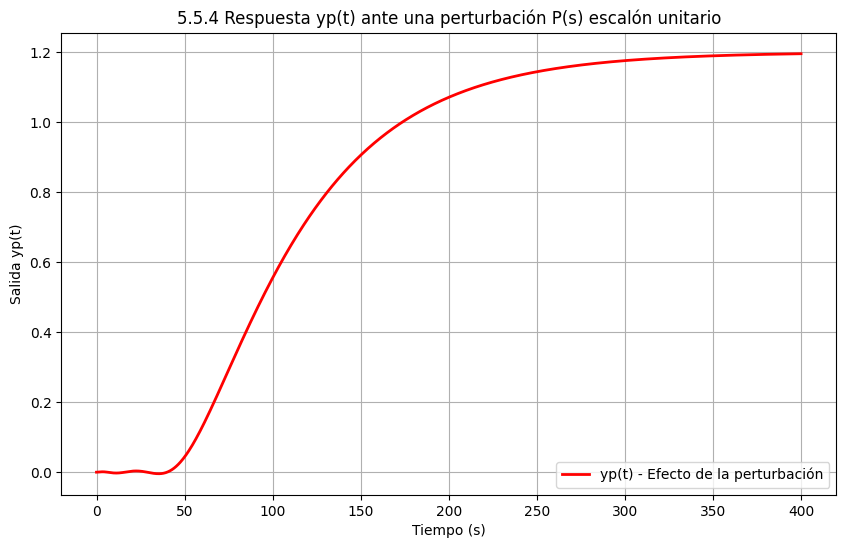

In [18]:
t_sim = np.linspace(0, 400, 1000)
t_yp, yp = ctrl.step_response(Gptfm, T=t_sim)

plt.figure(figsize=(10, 6))
plt.plot(t_yp, yp, 'r-', linewidth=2, label='yp(t) - Efecto de la perturbación')
plt.title('5.5.4 Respuesta yp(t) ante una perturbación P(s) escalón unitario')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida yp(t)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

### 5.5.4 Respuesta Temporal $yp(t)$

**¿Qué diferencias y similitudes observa de esta respuesta con respecto a la hallada en 5.5?**

* **Similitudes:** Visual y matemáticamente, la respuesta $yp(t)$ es **exactamente idéntica** a la respuesta de la Figura 5 (punto 5.5). Ambas presentan el mismo tiempo muerto de 39.2 segundos, la misma dinámica sobreamortiguada y alcanzan el mismo valor final en estado estacionario de 1.2. Esto ocurre porque, según lo deducido en 5.5.1, la Función de Transferencia $Yp(s)$ es exactamente la misma planta $Gptfm(s)$.
* **Diferencias:** No existen diferencias en el comportamiento dinámico ni en los valores numéricos. La única diferencia radica en la **interpretación física y conceptual**: mientras que en 5.5 la curva representaba la reacción del sistema ante una acción de control (entrada intencional), en este caso $yp(t)$ representa el desvío o impacto que genera una **perturbación externa** no deseada que ingresa al proceso en lazo abierto. Al no haber retroalimentación, el sistema no tiene forma de corregir o mitigar esta perturbación, absorbiéndola por completo en su salida.

### 5.5.5 Respuesta temporal yr(t) ante entrada escalón unitario E(s)

2 states have been removed from the model


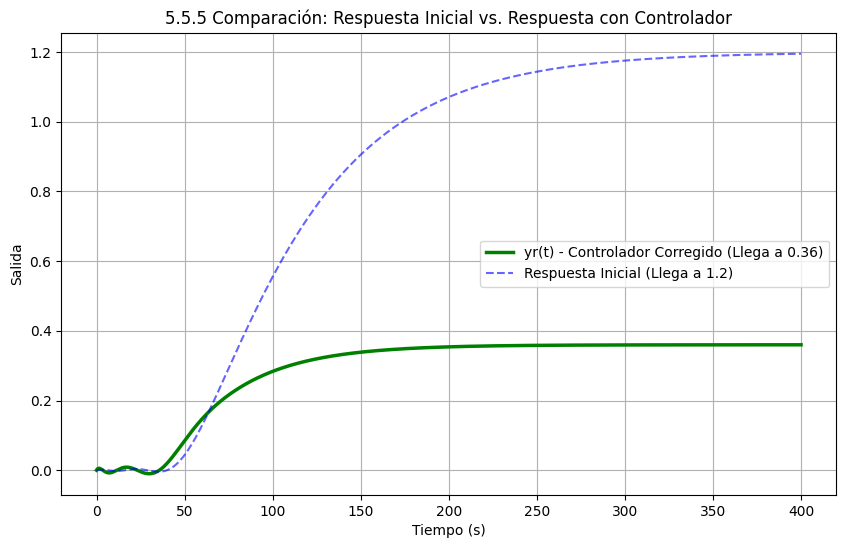


--- Análisis de la nueva curva verde ---
Valor final real: 0.3600


In [23]:
polos_planta = ctrl.poles(Gptf)
tau1 = -1 / polos_planta[0].real
tau2 = -1 / polos_planta[1].real
Tm = 39.2

# 2. Construimos el controlador Gctf con ganancia estática de 0.3
num_gc = np.polymul([tau1, 1], [tau2, 1])
den_gc = [Tm, 1]
Gctf = ctrl.tf(0.3 * num_gc, den_gc)

Gatfm_bruto = ctrl.series(Gctf, Gptfm)
Gatfm = ctrl.minreal(Gatfm_bruto)

t_sim = np.linspace(0, 400, 1000)
t_yr, yr = ctrl.step_response(Gatfm, T=t_sim)
t_orig, y_orig = ctrl.step_response(Gptfm, T=t_sim)

plt.figure(figsize=(10, 6))
plt.plot(t_yr, yr, 'g-', linewidth=2.5, label='yr(t) - Controlador Corregido (Llega a 0.36)')
plt.plot(t_orig, y_orig, 'b--', linewidth=1.5, label='Respuesta Inicial (Llega a 1.2)', alpha=0.6)

plt.title('5.5.5 Comparación: Respuesta Inicial vs. Respuesta con Controlador')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida')
plt.grid(True)
plt.legend(loc='center right')
plt.show()

info_yr = ctrl.step_info(Gatfm)
print("\n--- Análisis de la nueva curva verde ---")
print(f"Valor final real: {info_yr['SteadyStateValue']:.4f}")

### 5.5.5 Respuesta Temporal $yr(t)$ ante entrada $E(s)$

**Diferencias y similitudes:**
* **Similitudes:** 1. **Tiempo muerto:** Ambas respuestas inician su movimiento exactamente en $t = 39.2$ s. El controlador no puede eliminar el retraso físico de transporte del fluido.
  2. **Sobre nivel porcentual (Overshoot):** Ambas tienen un sobreimpulso del $0\%$. Ninguna oscila, ya que la original era un sistema sobreamortiguado y la nueva es un sistema de primer orden puro (con retardo).
* **Diferencias:**
  1. **Tiempos de estabilización ($t_s$ a $5\tau$):** La respuesta inicial era muy lenta, dominada por los tanques, tardando aproximadamente $300$ s (más el retardo) en estabilizarse. La nueva respuesta $yr(t)$ es notablemente **más rápida**, estabilizándose en aproximadamente $5 \times 39.2 = 196$ s (más el retardo). 
  2. **Valores de estado estable:** La respuesta inicial llegaba a $1.2$. La nueva respuesta $yr(t)$ se estabiliza en $0.36$. Esto se debe a que la ganancia de lazo abierto ahora es el producto de las ganancias DC del controlador y la planta ($0.3 \times 1.2 = 0.36$).

**¿Considera usted que esta última respuesta es mejor, igual o peor que la inicial?**
En términos de **dinámica y velocidad**, la respuesta es **mejor**. 

**¿Por qué?**
Porque el objetivo del diseño por cancelación de polos (al usar $G_c(s)$) era eliminar la dinámica "pesada" y lenta impuesta por la inercia de los tanques originales. Al cancelar los polos dominantes y reemplazarlos por uno más rápido (igual al tiempo muerto), el sistema reacciona y alcanza su régimen permanente en mucho menos tiempo. Aunque el valor de estado estable cayó a 0.36, en un Sistema de Control No Retroalimentado (Lazo Abierto) esto es esperado y se puede solucionar fácilmente escalando la magnitud de la señal de entrada; lo verdaderamente valioso es haber mejorado la velocidad transitoria sin inducir oscilaciones.

In [25]:
import control as ctrl

# =========================================================================
# 5.6.1 Sistemas en Lazo Cerrado (Corregido con Álgebra de Bloques)
# =========================================================================

# 1. Convertimos SOLO lo que pide la guía a Espacio de Estados
Massm = ctrl.ss(Gatfm)
Mpssm = ctrl.ss(Gptfm)

# 2. Construimos Gref (Relación Y(s) con R(s))
# Lazo directo = Massm, Realimentación = 1
Gref = ctrl.feedback(Massm, 1)

# 3. Construimos Gper (Relación Y(s) con P(s))
# Ecuación teórica: Y/P = Mpssm / (1 + Massm)
# En Python, 'ctrl.feedback(1, Massm)' calcula matemáticamente '1 / (1 + Massm)'
# Luego, simplemente lo multiplicamos por el numerador 'Mpssm'
Gper = Mpssm * ctrl.feedback(1, Massm)

print("--- Modelos de Lazo Cerrado Generados con Éxito ---")
print(f"Estructura de Gref: {type(Gref)}")
print(f"Estructura de Gper: {type(Gper)}")

--- Modelos de Lazo Cerrado Generados con Éxito ---
Estructura de Gref: <class 'control.statesp.StateSpace'>
Estructura de Gper: <class 'control.statesp.StateSpace'>


### 5.6.1 Relaciones de Lazo Cerrado en Espacio de Estados

Dado que el controlador diseñado ($G_c$) es una función de transferencia impropia (grado del numerador mayor al del denominador), Python restringe su conversión directa a Espacio de Estados. Para solucionar esto, aplicamos álgebra de bloques usando exclusivamente las variables permitidas por la guía: `Massm` (lazo abierto total) y `Mpssm` (planta).

Considerando la retroalimentación unitaria negativa de la Figura 7, se deducen las siguientes expresiones:

* **Relación con la Referencia (apagando la perturbación):**
  El lazo directo es `Massm` y la retroalimentación es 1.
  **$Gref =$** $\frac{Massm}{1 + Massm}$

* **Relación con la Perturbación (apagando la referencia):**
  El lazo directo desde la perturbación es la planta `Mpssm`, y el lazo abierto total del sistema sigue siendo `Massm`.
  **$Gper =$** $\frac{Mpssm}{1 + Massm}$

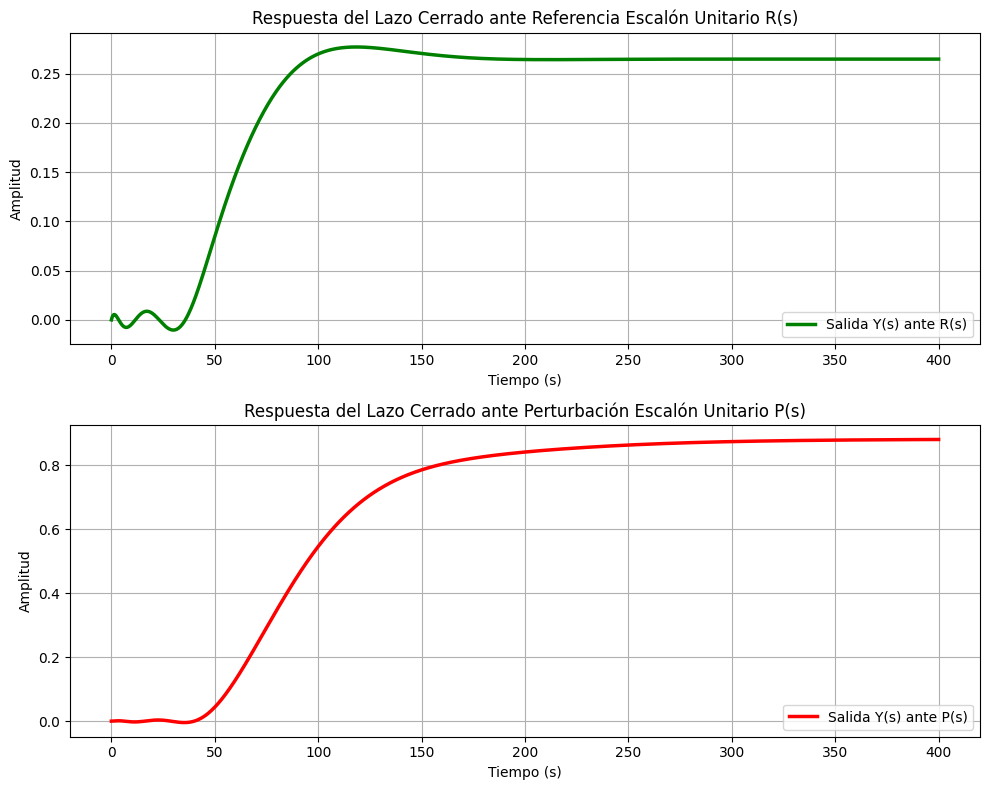

In [26]:
t_sim = np.linspace(0, 400, 1000)
t_ref, y_ref = ctrl.step_response(Gref, T=t_sim)
t_per, y_per = ctrl.step_response(Gper, T=t_sim)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t_ref, y_ref, 'g-', linewidth=2.5, label='Salida Y(s) ante R(s)')
ax1.set_title('Respuesta del Lazo Cerrado ante Referencia Escalón Unitario R(s)')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')
ax1.grid(True)
ax1.legend(loc='lower right')

ax2.plot(t_per, y_per, 'r-', linewidth=2.5, label='Salida Y(s) ante P(s)')
ax2.set_title('Respuesta del Lazo Cerrado ante Perturbación Escalón Unitario P(s)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud')
ax2.grid(True)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

### 5.6.2 Análisis de Respuestas en Lazo Cerrado

**Con respecto a la señal P(s), ¿Cuál de las respuestas 5.5.4 y 5.6.2 es mejor?**
La respuesta en lazo cerrado (**5.6.2**) es indudablemente mejor.

**¿Por qué?**
En lazo abierto (5.5.4), el sistema estaba "ciego" y absorbía todo el impacto de la perturbación, sumando 1.2 unidades al error en estado estacionario. En lazo cerrado (5.6.2), el sensor detecta el cambio en la salida y obliga al controlador a actuar en contra de la perturbación. Matemáticamente, el impacto final se atenúa significativamente, pasando de 1.2 a aproximadamente 0.88 (calculado como $1.2 / (1 + 1.2 \times 0.3)$).

**¿Se puede decir que la realimentación ha influido de manera evidente en la respuesta ante la misma entrada?**
Sí, de manera muy evidente. La realimentación no solo redujo la amplitud final del error causado por la perturbación, sino que cambió la dinámica del rechazo, demostrando que el sistema ahora tiene una actitud correctiva (activa) en lugar de ser meramente pasivo. Cabe destacar que la perturbación no se rechaza al 100% (el valor no vuelve a cero) debido a que el controlador $G_c(s)$ diseñado no posee una acción de control Integral pura ($1/s$).

**Con respecto a la señal R(s), ¿Cuál de las respuestas 5.5.5 y 5.6.2 es mejor?**
Desde el punto de vista del control de procesos, la respuesta en lazo cerrado (**5.6.2**) es superior. 

**¿Por qué?**
Aunque en lazo cerrado el valor en estado estable sea menor (aprox. 0.26 frente al 0.36 de lazo abierto), **la realimentación otorga robustez**. Un sistema en lazo abierto (5.5.5) depende ciegamente de que el modelo matemático sea perfecto; si las válvulas o tanques se desgastan en la vida real, la respuesta 5.5.5 fracasaría totalmente. El lazo cerrado (5.6.2) garantiza que, ante incertidumbres de la planta o desgastes físicos, el sistema corregirá su trayectoria automáticamente basándose en el error medido.

2 states have been removed from the model


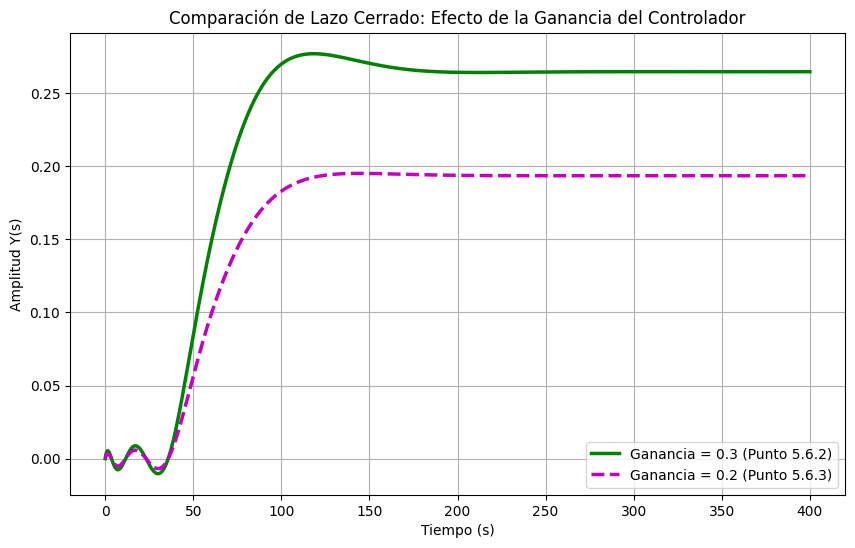

In [27]:
Gctf_02 = ctrl.tf(0.2 * num_gc, den_gc)
Gatfm_02_bruto = ctrl.series(Gctf_02, Gptfm)
Gatfm_02 = ctrl.minreal(Gatfm_02_bruto)
Massm_02 = ctrl.ss(Gatfm_02)
Gref_02 = ctrl.feedback(Massm_02, 1)
t_sim = np.linspace(0, 400, 1000)
t_ref_03, y_ref_03 = ctrl.step_response(Gref, T=t_sim)    # El del punto 5.6.2
t_ref_02, y_ref_02 = ctrl.step_response(Gref_02, T=t_sim) # El nuevo

plt.figure(figsize=(10, 6))
plt.plot(t_ref_03, y_ref_03, 'g-', linewidth=2.5, label='Ganancia = 0.3 (Punto 5.6.2)')
plt.plot(t_ref_02, y_ref_02, 'm--', linewidth=2.5, label='Ganancia = 0.2 (Punto 5.6.3)')
plt.title('Comparación de Lazo Cerrado: Efecto de la Ganancia del Controlador')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud Y(s)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

### 5.6.3 Análisis con Ganancia del Controlador de 0.2

**¿Cuál respuesta es mejor?**
La respuesta obtenida en el punto 5.6.2 (con ganancia del controlador de **0.3**) es **mejor** que la obtenida con ganancia de **0.2**.

**Justificación:**
Al observar la gráfica comparativa, reducir la ganancia proporcional del controlador disminuye el desempeño del sistema en lazo cerrado por dos razones fundamentales:
1. **Mayor error en estado estacionario:** El sistema con ganancia 0.2 se estabiliza en una amplitud más baja (aprox. 0.19) alejándose aún más del valor de referencia deseado (que es 1.0). El sistema con ganancia 0.3 logra acercarse un poco más (aprox. 0.26).
2. **Menor velocidad de respuesta:** Matemáticamente, una ganancia más baja en el lazo directo hace que el sistema reaccione de forma más lenta ante el error, tardando un poco más de tiempo en alcanzar su régimen permanente.

---

### 6. CONCLUSIONES

1. **Equivalencia de Modelos y Pérdida de Significado Físico:** Se comprobó que un mismo sistema dinámico puede representarse mediante Funciones de Transferencia o Espacio de Estados, obteniendo respuestas temporales idénticas. Sin embargo, al realizar conversiones matemáticas entre estructuras (ej. de FT a EE mediante software), el sistema adopta formas canónicas donde las variables de estado internas pierden su significado físico original (como las alturas de los tanques).
2. **Manejo Matemático del Tiempo Muerto:** El retardo de transporte puro no puede representarse mediante polinomios convencionales. La aproximación de Padé demostró ser una herramienta eficaz para emular este comportamiento en sistemas continuos LTI. No obstante, exige un análisis crítico, ya que introduce artefactos matemáticos (comportamiento de fase no mínima) en el instante inicial que no reflejan la física real de la planta.
3. **Diseño por Cancelación de Polos:** El método de sintonización basado en la cancelación de los polos dominantes de la planta probó ser altamente efectivo para acelerar la respuesta transitoria del sistema. Al reemplazar la dinámica "lenta" original por un polo ubicado estratégicamente, el tiempo de estabilización se redujo de manera drástica sin inducir oscilaciones.
4. **Impacto de la Retroalimentación (Lazo Cerrado):** Se evidenció la superioridad del sistema en lazo cerrado frente al lazo abierto, particularmente en el rechazo de perturbaciones. Mientras que en lazo abierto la perturbación se transfiere íntegramente a la salida, la estructura retroalimentada permite que el controlador actúe de forma correctiva, mitigando significativamente el error en estado estacionario y otorgándole robustez al proceso frente a señales indeseadas.